In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import tiktoken
from tqdm import tqdm
import math

In [2]:
def extract_step_into_traj(msgs, idx, bypass_filter=False):
    out = [f'<step id="{idx}">']
    for msg in msgs:
        tag_params = ''
        content = msg['content']
        if msg['role'] == 'user':
            tag = 'user'
        elif msg['role'] == 'assistant':
            tag = 'talk' if bypass_filter else 'think'
            if msg.get('agent_erased', ''):
                out.append(msg['agent_erased'])
                continue
        elif msg['role'] == 'tool':
            tag = 'result'
            if msg['agent_caller'][0]=='think':
                tag = 'talk' if bypass_filter else 'think'
                content = (msg['agent_caller'][1] or {}).get('thought', '')
                content = f'\n{content.strip()}\n'
        else:
            raise ValueError(f'wtf msg role {msg["role"]}')

        if content.strip():
            out.append(f'<{tag}{tag_params}>{content}</{tag}>')
        if msg['role'] == 'assistant' and msg.get('tool_calls', None):
            for tool_call in msg['tool_calls']:
                tool_name = tool_call["function"]["name"]
                tool_arguments = tool_call["function"].get("arguments", "").strip()
                out.append(f'<call tool="{tool_name}">{tool_arguments}</call>')

    out += ['</step>']
    return '\n'.join(out)

In [3]:
_token_encoding = tiktoken.encoding_for_model('gpt-4o')
def count_token(s):
    #return len(s)
    return len(_token_encoding.encode(s))

In [4]:
def process_tech(basep):
    t_skip = []
    t_before = []
    t_after = []
    
    for p in tqdm(list(basep.glob('*.json'))):
        with p.open() as f:
            d = json.load(f)

        for idx, m in enumerate(d['messages']):
            if m['role']=='assistant':
                if 'agent_erased' in m:
                    t_before.append(count_token(m['agent_erased']))
                    t_after.append(count_token(m['content']))
                elif idx!=len(d['messages'])-1:
                    m_tool = d['messages'][idx+1]
                    if m_tool['role']!='tool':
                        continue
                    serialized = extract_step_into_traj([m, m_tool], idx)
                    t_skip.append(count_token(serialized))

    return t_skip, t_before, t_after

In [5]:
results = [
    ('SbV+Claude', process_tech(Path('trajs/eval/gpt5mini_for_claude4'))),
    ('SbV+Gemini', process_tech(Path('trajs/eval/gpt5mini_for_gemini25pro'))),
    ('MSbF+Claude', process_tech(Path('trajs/multi/llm_gpt5mini'))),
    ('MSbF+Gemini', process_tech(Path('trajs/multi/gpt5mini_for_gemini25pro'))),
]

100%|██████████| 299/299 [00:07<00:00, 37.57it/s]


In [6]:
def frange(start, stop, step):
    while start < stop - 1e-6:
        yield start
        start += step

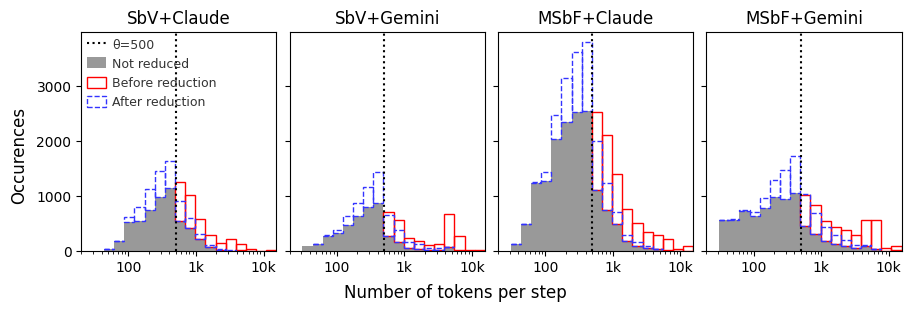

In [16]:
fig, axs = plt.subplots(1, 4, sharey=True, figsize=(9, 3), constrained_layout=True)
fig.supylabel('Occurences')
fig.supxlabel('Number of tokens per step')
for idx, (name, (t_skip, t_before, t_after)) in enumerate(results):
    x_min = 1.49
    x_max = 4.19
    x_step = .15
    xs = list(frange(x_min, x_max, x_step))
    
    ax = axs[idx]
    ax.set_title(name)
    
    def to_hist(li):
        ys = [0 for _ in range(len(xs))]
        for x in li:
            y = int((math.log10(x) - x_min) // x_step)
            if y >= len(ys):
                y = len(ys)-1
            if y < 0:
                y = 0
            ys[y] += 1
        return ys

    ax.set_xlim(x_min, x_max)
    ax.set_xticks([2, 3, 4])
    ax.set_xticks([math.log10(a*b) for a in range(2, 10) for b in [10, 100, 1000]], minor=True)
    ax.set_xticklabels(['100', '1k', '10k'])

    y_skip = to_hist(t_skip)
    y_before = to_hist(t_before)
    y_after = to_hist(t_after)

    def remove_zero(xs, ys, bottom):
        new_xs = []
        new_ys = []
        new_bottom = []
        for x, y, b in zip(xs, ys, bottom):
            if y > 0:
                new_xs.append(x)
                new_ys.append(y)
                new_bottom.append(b)
        return {'x': new_xs, 'height': new_ys, 'bottom': new_bottom}

    ax.bar(xs, y_skip, width=x_step, align='edge', color='#999', zorder=0, label='Not reduced')
    ax.bar(**remove_zero(xs, y_before, y_skip), width=x_step, align='edge', fill=False, ec='#f00', zorder=1, label='Before reduction')
    ax.bar(**remove_zero(xs, y_after, y_skip), width=x_step, align='edge', fill=False, ls='--', ec='#33f', zorder=2, label='After reduction')

    # draw a vertical line at x=500
    ax.axvline(x=math.log10(500), color='#000', ls=':', zorder=3, label='θ=500')

    if idx==0:
        ax.legend(loc='upper left', fontsize=9, frameon=False, borderpad=0, labelspacing=.5, handlelength=1.5, handleheight=1, handletextpad=.5, labelcolor='#333')

plt.savefig('evaluation-length.pdf', bbox_inches='tight')
plt.show()